<a href="https://colab.research.google.com/github/divyatejaswi86/Datascience-projects/blob/main/trader_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Objective
Analyze the relationship between Bitcoin market sentiment (Fear/Greed) and trader behavior and performance on Hyperliquid.

## Data Overview
Two datasets were used:
1. Hyperliquid trader transaction data
2. Bitcoin Fear and Greed sentiment data

Both datasets were checked for missing values and data types. No missing values were found.

## Data Preparation
Trade timestamps were converted to datetime format and aggregated at daily account level.
Daily trader metrics (PnL, trade count, win rate, trade size, and long/short ratio) were created.
The trader data was merged with daily Fear/Greed sentiment using the date field.

## Analysis Summary
Trader performance and behavior were compared across Fear and Greed days using daily aggregated metrics.
Differences in PnL, trade frequency, and trading behavior were analyzed.

## Key Insights
1. Trader performance varies between Fear and Greed days, with higher PnL volatility during Fear periods.
2. Traders tend to trade more frequently during Greed days compared to Fear days.
3. Losses are larger on Fear days, indicating increased downside risk during negative market sentiment.

## Strategy Recommendations
1. During Fear days, traders should reduce position sizes to limit drawdowns.
2. During Greed days, consistent traders can increase trade frequency cautiously.


In [ ]:
import pandas as pd
df = pd.read_csv('historical_data.csv')
df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [ ]:
import pandas as pd
df1 = pd.read_csv('fear_greed_index.csv')
df1

,timestamp,value,classification,date
0,1517463000,30,Fear,01-02-2018
1,1517549400,15,Extreme Fear,02-02-2018
2,1517635800,40,Fear,03-02-2018
3,1517722200,24,Extreme Fear,04-02-2018
4,1517808600,11,Extreme Fear,05-02-2018
...,...,...,...,...
2639,1745818200,54,Neutral,28-04-2025
2640,1745904600,60,Greed,29-04-2025
2641,1745991000,56,Greed,30-04-2025
2642,1746077400,53,Neutral,01-05-2025


In [ ]:
# @title checking size of dataset of historical data
print("no.of rows is ",df.shape[0])
print("no.of columns is ",df.shape[1])


no.of rows is  211224
no.of columns is  16


In [ ]:
# checking size of dataset of fear greed data
print("no.of rows is ",df1.shape[0])
print("no.of columns is ",df1.shape[1])

no.of rows is  2644
no.of columns is  4


In [ ]:
# Size function
df.size

3379584

In [ ]:
# Size function
df1.size

10576

In [ ]:
# Describe function
df.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [ ]:
# Describe function
df1.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [ ]:
# Info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
# Info of the dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
# Checking null values
df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
# Checking null values
df1.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms')
df['date'] = df['Timestamp'].dt.date



In [ ]:
df1['timestamp'] = pd.to_datetime(df1['timestamp'], unit='s')
df1['date'] = df1['timestamp'].dt.date


In [ ]:
df[['Timestamp','date']].head()
df1[['timestamp','date','classification']].head()


,timestamp,date,classification
0,2018-02-01 05:30:00,2018-02-01,Fear
1,2018-02-02 05:30:00,2018-02-02,Extreme Fear
2,2018-02-03 05:30:00,2018-02-03,Fear
3,2018-02-04 05:30:00,2018-02-04,Extreme Fear
4,2018-02-05 05:30:00,2018-02-05,Extreme Fear


In [ ]:
df['is_win'] = df['Closed PnL'] > 0

df['position'] = df['Side'].str.lower()
df['position'] = df['position'].replace({'buy':'long', 'sell':'short'})


In [ ]:
daily_df = df.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trades_count=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    avg_trade_size_usd=('Size USD', 'mean'),
    long_ratio=('position', lambda x: (x == 'long').mean())
).reset_index()


In [ ]:
daily_df.head()


,Account,date,daily_pnl,trades_count,win_rate,avg_trade_size_usd,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,0.025974,14810.891818,0.300866
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,0.405542,16345.241940,0.468415
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,0.531250,2492.749906,0.453125
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,0.435041,1693.351684,0.432494
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,0.442369,1533.468395,0.403268


In [ ]:
daily_df = daily_df.merge(
    df1[['date', 'classification']],
    on='date',
    how='left'
)


In [ ]:
daily_df['classification'].value_counts()


,count
classification,
Greed,32
Fear,32
Neutral,8
Extreme Greed,5


In [ ]:
summary = daily_df.groupby('classification')[[
    'daily_pnl',
    'win_rate',
    'trades_count',
    'avg_trade_size_usd'
]].mean()


In [ ]:
summary

,daily_pnl,win_rate,trades_count,avg_trade_size_usd
classification,,,,
Extreme Greed,35393.098355,0.336609,1392.40000,4344.447836
Fear,209372.662205,0.415878,4183.46875,5926.522723
Greed,99675.516731,0.374074,1134.03125,5839.310974
Neutral,19842.797260,0.260683,892.62500,3793.444161


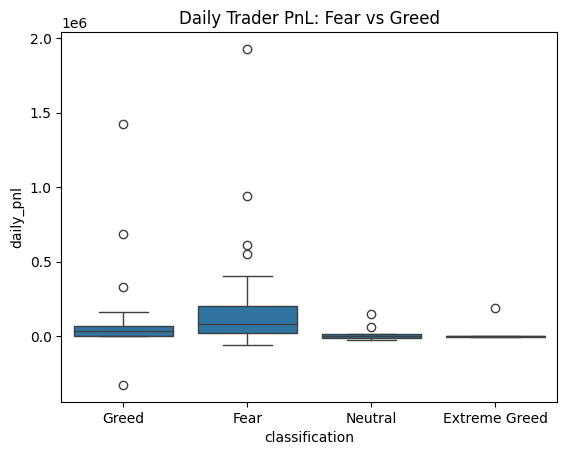

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='daily_pnl', data=daily_df)
plt.title("Daily Trader PnL: Fear vs Greed")
plt.show()
